# High-Resolution Image Synthesis with Latent Diffusion Models (LDMs)

In this tutorial, we will implement and train an **unconditional** [Latent Diffusion Model (LDM)](https://arxiv.org/abs/2112.10752) for high-resolution image synthesis using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) library, which is built on top of [PyTorch](https://pytorch.org/). All experiments in this tutorial were run on a consumer laptop with an Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM). The code is designed to be lightweight so it can run on modest hardware, at the cost of longer training times and lower image resolution compared to large-scale LDM setups. On GPUs with more memory, you can increase image resolution, model size, and batch size for better sample quality and faster convergence.
<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ldm.png" alt="UnCLIP overview" width="1000"/>
  <br>
  <em>An overview of the LDM pipeline, Rombach, et al. (2022)</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Perceptual Compression with a Variational Autoencoder (VAE)](#perceptual-compression-with-a-variational-autoencoder-vae)
- [Training an LDM Model](#training-an-ldm-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

We'll use the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/). Each image is RGB with shape `(3, 96, 96)`.

In [ ]:
# Import necessary libraries
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.io import read_image
from torchvision.transforms import Resize, CenterCrop
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import glob

# Import TorchDiff components
import torchdiff
from torchdiff.ldm import AutoencoderLDM, TrainAE, TrainLDM, SampleLDM
from torchdiff.ddpm import SchedulerDDPM, ReverseDDPM, ForwardDDPM
from torchdiff.utils import DiffusionNetwork, Metrics, mse_loss

In [2]:
print(torchdiff.__version__)

2.4.0


## Download the STL-10 Dataset

Let's download the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset using [Torchvision](https://pytorch.org/vision/stable/).

In [ ]:
# Define data transformations: resize, crop, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

# Download STL-10 train and test sets
train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform)

### Use a Subset of the Dataset

We'll train on a smaller subset (10,000 images) for faster iterations. This is perfect for testing and prototyping the full pipeline.

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Create training and test subsets
train_subset = Subset(train_dataset, torch.randperm(len(train_dataset))[:10000])
test_subset = Subset(test_dataset, torch.randperm(len(test_dataset))[:100])

# Create data loaders with shuffling and batching
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

### Visualizing Training Images

In [6]:
stl10_classes = ['airplane', 'bird', 'car', 'cat', 'deer', 
                 'dog', 'horse', 'monkey', 'ship', 'truck']

def denormalize(tensor):
    """Convert tensor from [-1, 1] back to [0, 1] for display"""
    return tensor * 0.5 + 0.5

def visualize_stl10_grid(dataloader, num_images=64):
    """
    Visualize STL-10 images in an 8x8 grid with labels
    """
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            break
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))
    fig.suptitle('STL-10 Dataset Sample (8x8 Grid)', fontsize=14)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)  
                img = torch.clamp(img, 0, 1)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{stl10_classes[all_labels[idx]]}', fontsize=10)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

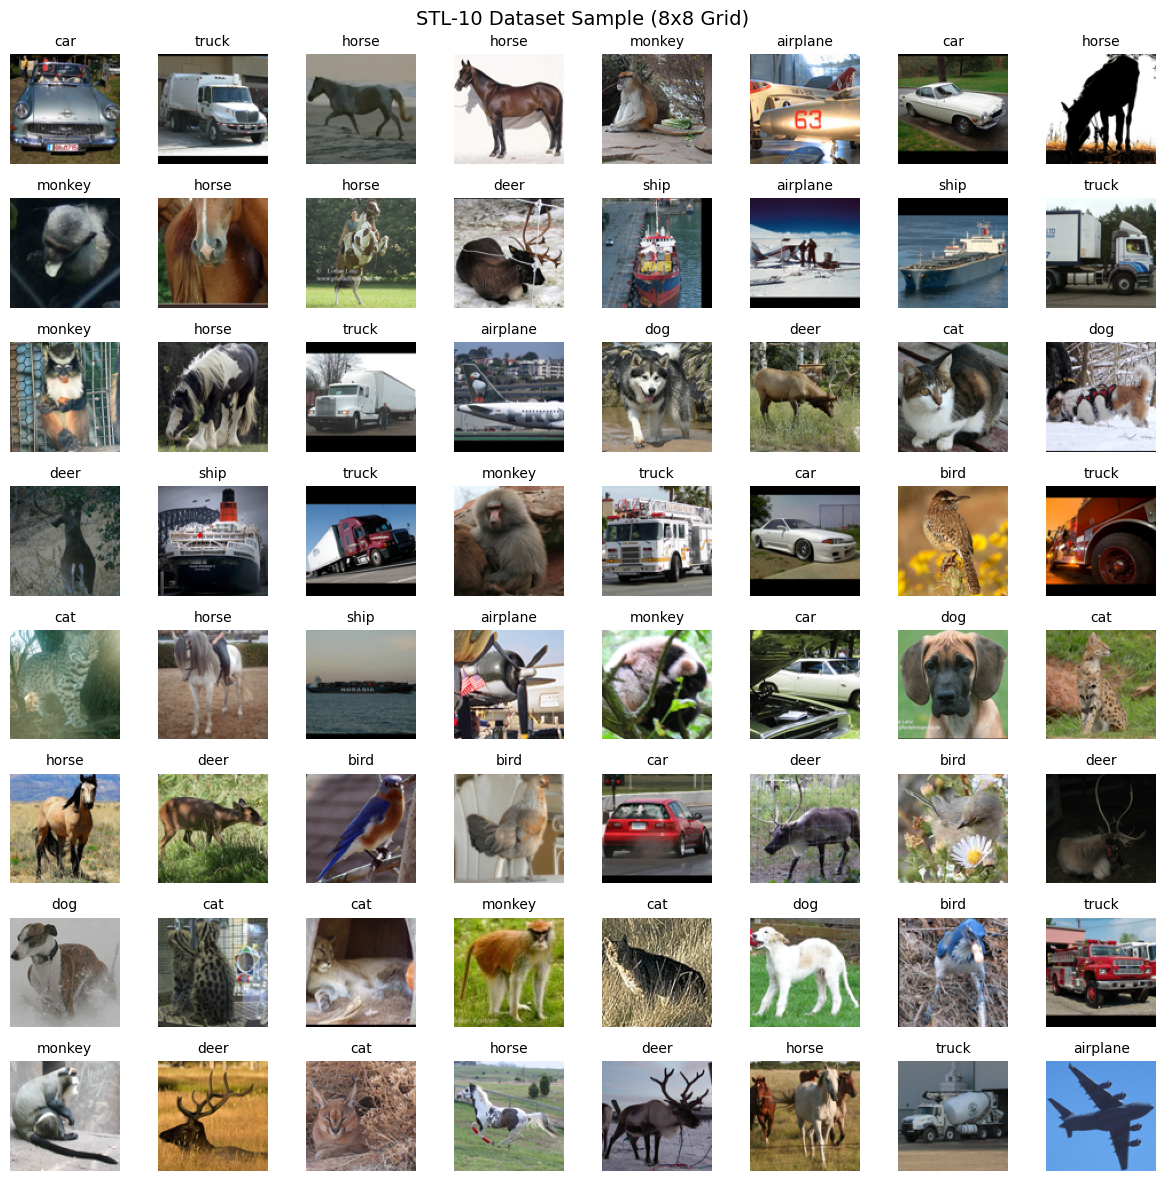

In [9]:
visualize_stl10_grid(train_loader, num_images=64)

## Perceptual Compression with a Variational Autoencoder (VAE)

Instead of training the diffusion model directly on images (which is memory-intensive), we'll train a VAE first to compress images into a latent space. This is more efficient and allows for better generation. The [`AutoencoderLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.AutoencoderLDM) compresses images from `(3, 96, 96)` down to `(2, 48, 48)` in the latent space, then decodes them back to the original shape.

In [ ]:
# Initialize the VAE (AutoencoderLDM)
comp_net = AutoencoderLDM(
    in_channels=3,
    down_channels=[64, 128],        # 2 downsampling blocks
    up_channels=[128, 64],          # 2 upsampling blocks
    out_channels=3,
    dropout_rate=0.2,
    latent_channels=2,              # Latent space has 2 channels
    num_heads=4,
    num_groups=8,
    num_layers_per_block=6,
    total_down_sampling_factor=2,   # Downsamples by 2x (96 -> 48)
    use_flash=True,                 # Use flash attention if available
    num_embeddings=256
)

# Load pre-trained VAE weights if available
#c = torch.load('vae_model.pth', map_location='cpu')
#comp_net.load_state_dict(c['model_state_dict'])

# Setup optimizer and loss
comp_optim = torch.optim.Adam(comp_net.parameters(), lr=1e-5)
comp_loss = nn.MSELoss()

# Create VAE trainer
vae_trainer = TrainAE(
    model=comp_net,
    optim=comp_optim,
    train_loader=train_loader,
    max_epochs=100,
    device="cuda",
    checkpoint=10,
    warmup_steps=300,
    kl_warmup_epochs=5,
    patience=100,
    use_ddp=False,              # Set to True for multi-GPU training
    grad_acc=8,
    log_freq=5,
    use_comp=False              # Model compilation (not needed here)
)

In [ ]:
# Check the VAE by encoding and decoding a sample image
x = torch.rand((1, 3, 96, 96)).to("cuda")
print(f"Original image type: {x.dtype}")
print(f"Original image shape: {x.size()}")

# Encode to latent space
z, loss = comp_net.encode(x)
print(f"Latent space shape: {z.size()}")

# Decode back to image space
rx = comp_net.decode(z)
print(f"Reconstructed image shape: {rx.size()}")

# Count total parameters
total_params = sum([p.numel() for p in comp_net.parameters()])
print(f"Total VAE parameters: {total_params:,}")

torch.float32
original size:  torch.Size([1, 3, 96, 96])
latent space shape:  torch.Size([1, 2, 48, 48])
reconstracted shape:  torch.Size([1, 3, 96, 96])
total model params:  2927749


In [20]:
vae_losses = vae_trainer()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09232986..1.0723205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.085298836..0.8334446].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.043138325..1.1177595].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07232672..1.0241365].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08894801..1.117694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11748022..1.0107335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08

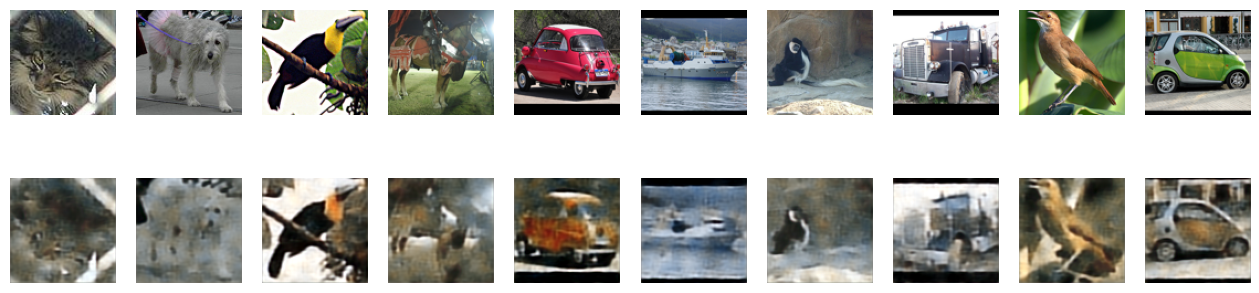

In [ ]:
# Visualize VAE reconstructions: original vs decoded
x, _ = next(iter(test_loader))
x = x.to('cuda')
comp_net.eval()

with torch.no_grad():
    x_hat, _, _, _ = comp_net(x)

# Unnormalize images from [-1, 1] to [0, 1] for display
def unnorm(img):
    return img * 0.5 + 0.5

# Create side-by-side comparison
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    # Original images
    axes[0, i].imshow(unnorm(x[i]).permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis('off')
    
    # Reconstructed images
    axes[1, i].imshow(unnorm(x_hat[i]).permute(1, 2, 0).cpu().numpy())
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()

## Training a Latent Diffusion Model (LDM)

Now we'll train a diffusion model in the latent space. We'll need a few key components:

- **DiffusionNetwork**: The main network that learns to predict and remove noise.
- **Optimizer**: AdamW to update model weights.
- **Loss Function**: Mean Squared Error to measure prediction accuracy.
- **Scheduler**: Defines the noise schedule for the diffusion process.

In [ ]:
# Create a DataLoader for diffusion model training with larger batch size
diff_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

In [ ]:
# Initialize the diffusion model (noise predictor)
diff_net = DiffusionNetwork(
    in_channels=2,              # Latent space has 2 channels
    down_channels=[64, 128, 256],
    mid_channels=[256, 256],
    up_channels=[256, 128, 64],
    down_sampling=[True, True],
    time_embed_dim=256,         # Timestep embedding dimension
    y_embed_dim=256,            # Conditional embedding dimension
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=4,
    cont_time=False,            # Discrete timesteps (not continuous)
    use_flash_attention=True    # Use flash attention if available
)

# Setup optimizer (AdamW is more stable than Adam for this task)
diff_optim = torch.optim.AdamW(
    [p for p in diff_net.parameters()], 
    lr=1e-4
)
print(f"Diffusion network parameters: {sum(p.numel() for p in diff_net.parameters()):,}")

# Create noise schedule (cosine schedule works well)
vs = SchedulerDDPM(schedule_type="cosine")

# Initialize forward and reverse diffusion models
fwd = ForwardDDPM(vs, pred_type='noise')
rwd = ReverseDDPM(vs, pred_type='noise')

# Load pre-trained diffusion weights if available
#c_ = torch.load('diff_model.pth', map_location='cpu')
#diff_net.load_state_dict(c_['model_state_dict_diff_net'])
#rwd.vs.load_state_dict(c_['scheduler_model'])
#fwd.vs.load_state_dict(c_['scheduler_model'])

# Create LDM trainer
diff_trainer = TrainLDM(
    diff_type='ddpm',
    fwd_diff=fwd,
    rwd_diff=rwd,
    diff_net=diff_net,
    comp_net=comp_net,              # Use the trained VAE
    optim=diff_optim,
    loss_fn=mse_loss,
    train_loader=diff_loader,
    max_epochs=100,
    device='cuda',
    store_path='diff_train',
    patience=200,
    warmup_steps=200,
    norm_range=(-1.0, 1.0),
    norm_output=True,
    grad_acc=4,
    log_freq=5,
    time_eps=1e-5,
    num_steps=400
)

9435010


In [32]:
diff_losses = diff_trainer()

### Key DDPM Components

We use these important classes from TorchDiff:

- **SchedulerDDPM**: Manages the noise schedule that controls the diffusion forward and reverse processes.
- **ReverseDDPM**: Handles the reverse diffusion process (converting noise back to images) during generation.

## Generate Images from Noise

In [ ]:
# Initialize the sampler for generating new images
sampler = SampleLDM(
    diff_type="ddpm",
    rwd_diff=rwd,
    diff_net=diff_net,
    comp_net=comp_net,              # Use the trained VAE decoder
    num_steps=1000,                 # Number of diffusion steps
    img_size=(96, 96),
    batch_size=20,
    in_channels=3,
    device="cuda",
    norm_range=(-1, 1)
)

In [ ]:
# Generate images! They will be saved to the "samples" directory
gen_imgs = sampler(save_path="samples")

Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:58<00:00, 17.16it/s]


### View the Generated Images

Let's display some of the images our trained model generated!

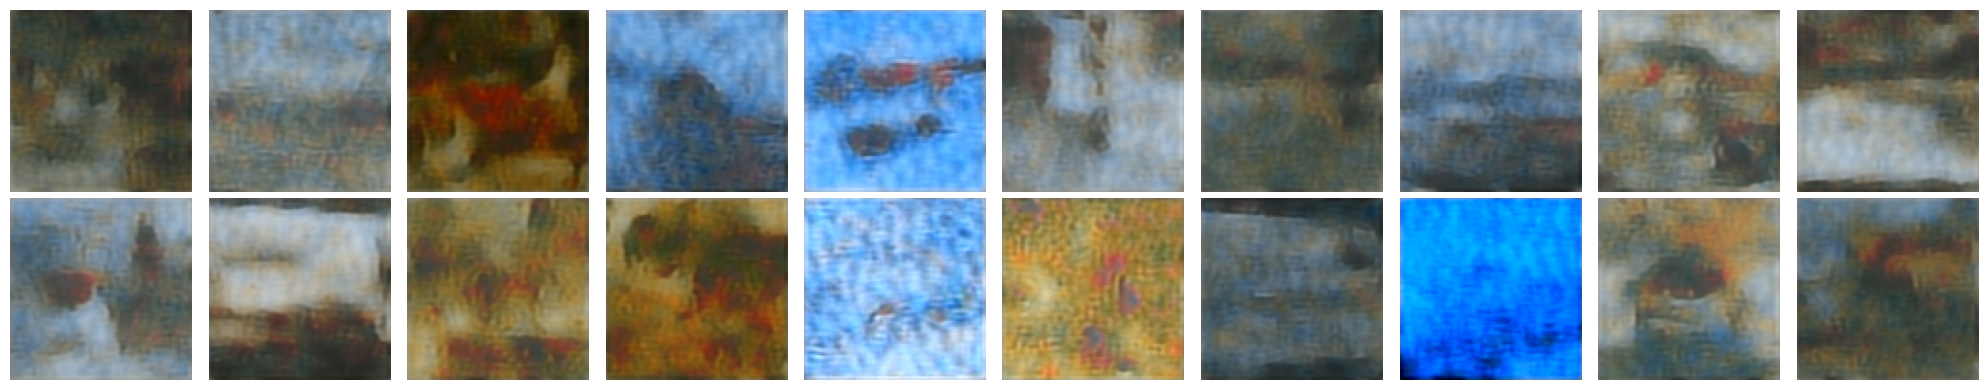

In [ ]:
# Load and display generated images in a grid
folder_path = "/home/loqman/Downloads/projs/TorchDiff/examples/ldm/samples"
num_images = 20 
rows, cols = 2, 10

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
fig.suptitle('Generated Images from LDM', fontsize=14)

for i in range(num_images):
    img_path = os.path.join(folder_path, f"img_{i+1}.png")
    img = Image.open(img_path).convert('RGB') 

    ax = axes[i // cols, i % cols]
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Understanding Image Quality

The generated images may not be perfect and that's okay! Here's why this tutorial uses a simplified setup:

- **Small Dataset**: We train on 10K images instead of the full dataset.
- **Limited Epochs**: Both VAE and diffusion models train for just 100 epochs (not enough for convergence).
- **Lightweight Models**: We use shallower architectures for faster training.
- **No Advanced Techniques**: We skip EMA (exponential moving average) and other optimizations.

**To improve results**: Use more data, train longer, use larger models, and apply advanced techniques like EMA.

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Latent Diffusion Models and Their Implementation in TorchDiff](https://medium.com/@samaniloqman91/latent-diffusion-models-and-their-implementation-in-torchdiff-7dc04c33c4f7)
- [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752)